# Sigmoid fitting with CurveCurator — EGF time course

A second, independent implementation of the sigmoid/T50 analysis in `Sigmoid_fitting.ipynb`,
built on **CurveCurator** (Kuster lab, [kusterlab/curve_curator](https://github.com/kusterlab/curve_curator)).

CurveCurator is a dose-response fitter. Nothing in its model is chemical, so the dose axis can
carry time instead — this notebook does that, and states exactly what the substitution costs.

## What CurveCurator adds that `src/curve_fitting.py` does not have

| | `src/curve_fitting.py` | CurveCurator |
|---|---|---|
| points per fit | 6 (the mean profile, SEM-weighted) | **24** (4 replicates × 6 timepoints, fitted simultaneously) |
| steepness | not identifiable → fixed by convention (`DEFAULT_FIXED_K = 10`) | estimated, because the replicates supply the degrees of freedom |
| significance | lack-of-fit F-test, BH-FDR vs a flat model | regularised F-test + **target-decoy FDR** + relevance score |
| loading normalisation | none (see CLAUDE.md → Known issues) | `normalization = true`, median centring in log space |
| non-sigmoidal sites | classified out first (`src/response_shapes.py`) | **no shape model at all** — see the caveat below |

## The substitution, precisely

CurveCurator's model (`curve_curator/models.py`, `LogisticModel.core`) is

$$y = \frac{\mathrm{front} - \mathrm{back}}{1 + 10^{\,\mathrm{slope}\,(x + \mathrm{pEC50})}} + \mathrm{back}$$

with `x` **already log10-transformed**: $x = \log_{10}(\mathrm{dose} \times \mathrm{dose\_scale})$,
built by `toolbox.build_drug_log_concentrations`. Substituting minutes for concentration:

| CurveCurator (dose) | here (time) |
|---|---|
| $x = \log_{10}(\mathrm{dose}\cdot\mathrm{scale})$ | $x = \log_{10}(t_{\min})$, with `dose_scale = '1e0'` |
| pEC50 $= -\log_{10}(\mathrm{EC50})$ | pEC50 $= -\log_{10}(T_{50})$, so $T_{50} = 10^{-\mathrm{pEC50}}$ min |
| `front` (plateau as $x\to-\infty$) | the ratio at $t = 0$, which is **1 by construction** → fixed |
| `back` (plateau as $x\to+\infty$) | the final level, as a ratio to the starve control |
| `slope` | steepness on the log-time axis — the `k` of `curve_fitting` |
| $y$ = ratio to control | $2^{\,\log_2 FC\ \mathrm{vs\ starve}}$ |

Fixing `front = 1.0` is the same argument that makes the model in `src/curve_fitting.py`
*anchored*: `log2:FC` at starve is identically zero, so the baseline is a constraint, not a
parameter worth a degree of freedom.

Log-time is not a concession to CurveCurator — it is what this data wanted anyway. On the
hme1_2 grid the 90-min point carries leverage 0.979 in linear time and 0.659 in log time.

## Two things that must not be glossed over

**1. CurveCurator is monotone-sigmoid only.** From its own FAQ: *"CurveCurator was specifically
optimized for dose-response data ... Other x-dimensions, such as time, can be processed ... but
CurveCurator will miss any non-sigmoidal behaviors."* On hme1_2 EGF, the majority of responsive
sites are transient or biphasic. The optimiser does not refuse them — it returns a number. So
the shape gate from `src/response_shapes.py` runs **before** the fit, exactly as in
`Sigmoid_fitting.ipynb`. `GATE_SHAPES = False` turns it off, which is worth doing once as a
deliberate cross-check of what CurveCurator's own statistics do with transient sites.

**2. Ratios, not fold changes.** CurveCurator divides each measurement by the mean of the
control channels and fits in ratio space. The input must therefore be **intensities**
(`raw:abs`), not `log2:FC` — handing it fold changes would fit a sigmoid to the logarithm of the
quantity the model expects. `build_curvecurator_input` rejects a log-space `data_type`. **(OBJECTION: I have to feed log2:abs, not raw:abs)**

## Installation

CurveCurator is **not** in the `TMT_Data_analysis` conda environment, and its authors recommend
a dedicated one:

```
conda create -n CurveCuratorEnv pip python=3.12
conda activate CurveCuratorEnv
pip install curve-curator
```

Then set `CURVECURATOR_EXECUTABLE` below to that environment's python (e.g.
`~/miniconda3/envs/CurveCuratorEnv/bin/python`), or leave it `None` if the `CurveCurator`
console script is on PATH. Everything up to and including the TOML is generated inside *this*
environment; only the fitting step crosses over.

### 📖 Explainer 0 — read this first: dose-response vocabulary, and why it is being used for time

*Cells titled **📖 Explainer** define the concepts this notebook uses and run nothing. The shared
statistical vocabulary — sigmoid, residual, weighted least squares, chi-square, degrees of freedom,
FDR, identifiability, censoring, Spearman correlation, leverage — is defined once, in Explainers 0–4
of `Sigmoid_fitting.ipynb`. This notebook adds only what is specific to CurveCurator.*

#### What this notebook is for

It is a **second, independent implementation** of the same analysis as `Sigmoid_fitting.ipynb`:
fit an S-shaped curve to each phosphosite's EGF time course and read off **T50**, the time at which
the site reaches half of its final level.

Two implementations of one analysis is not duplicated effort. If two pipelines that differ in model,
in the data they see, in the space they fit and in normalisation still order the sites the same way,
that ordering is a property of the data rather than of either pipeline. If they disagree, the
disagreement localises which of those four differences matters. That is the entire purpose of the
cross-check section near the end.

#### What a dose-response curve is

CurveCurator (Kuster lab) was built for **pharmacology**, not for time courses. Its native
experiment is: treat cells with a drug at increasing concentrations, measure a response at each, and
fit an S-shaped curve through concentration vs response. The standard vocabulary:

| term | meaning |
|---|---|
| **dose-response curve** | response plotted against drug concentration, usually on a log-concentration axis |
| **EC50** | the **half-maximal effective concentration** — the dose producing half of the maximum effect. The standard measure of **potency** |
| **pEC50** | $-\log_{10}(\mathrm{EC50})$. A convenience: it turns a concentration spanning orders of magnitude into a small number, and *higher pEC50 = more potent* because of the minus sign |
| **efficacy** | how big the maximum effect is — the *height* of the curve, as opposed to its *position* |
| **front / back** | the two plateaus of the curve: the response as dose → 0, and as dose → ∞ |
| **slope (Hill slope)** | how steep the transition is — the `k` of `src/curve_fitting.py` |
| **four-parameter logistic (4PL)** | the standard dose-response model: front, back, slope, EC50 |

#### The substitution

Nothing in that model is chemical. It is a monotone S-shaped function of a log-scaled x-axis, so the
x-axis can carry **minutes since stimulation** instead of concentration. Then:

- EC50 (a concentration) becomes **T50** (a time);
- pEC50 = $-\log_{10}(T_{50})$, so with time in minutes it is **negative** for any T50 above one
  minute, and larger pEC50 means *faster*, not slower. This sign flip is the single easiest thing to
  get wrong in this notebook, which is why sanity check 1 tests the round trip;
- `front` = the level at $t \to 0$, i.e. the starve control. Because every value is expressed as a
  ratio to that control, `front = 1` **by construction**, and fixing it is exactly the *anchoring*
  argument from `Sigmoid_fitting.ipynb` (a baseline that is known by definition should be a
  constraint, not spend a degree of freedom);
- `back` = the final level, as a ratio to starve. `log2(back/front)` converts it into the log2
  fold-change units the rest of the project uses.

⚠️ Note the axis differs slightly from the other notebook: CurveCurator uses $x = \log_{10}(t)$,
while `src/curve_fitting.py` uses $x = \log_{10}(t+1)$. The `+1` exists there so $t=0$ maps to $x=0$;
CurveCurator instead handles the zero dose as a separate control channel, parked far to the left of
the axis. It changes nothing about the fitted timepoints, but it is why the two sets of `x` values
are not numerically identical.

#### The one real gain: 24 points instead of 6

`src/curve_fitting.py` fits the **mean** profile — 6 numbers, with the replicate scatter entering
only as a weight. CurveCurator fits **every replicate as its own observation**: 4 replicates × 6
timepoints = 24 points per curve, all at once.

Why that matters: degrees of freedom. With 6 points and 3 parameters, only 3 are left over to test
the fit with, which is why `Sigmoid_fitting.ipynb` had to fix the steepness by convention (it was
not **identifiable** — the data could not determine it). With 24 points there is room to estimate
the steepness per site. **Whether that actually works is the open question this notebook exists to
answer** — see the `Curve Slope` histogram below. If the slope still piles up at a bound, the limit
is the 5-point time grid and no fitter can repair it.

#### The two things that must not be glossed over

**1. CurveCurator is monotone-sigmoid only.** From its own FAQ: *"CurveCurator was specifically
optimized for dose-response data ... Other x-dimensions, such as time, can be processed ... but
CurveCurator will miss any non-sigmoidal behaviors."* On hme1_2 EGF the majority of responsive sites
rise and then fall, which a monotone curve structurally cannot represent — and the optimiser does
not refuse them, it returns a plausible, wrong number. So the shape gate from
`src/response_shapes.py` runs **before** anything is handed over.

**2. Ratios, not fold changes.** CurveCurator forms its own ratios by dividing each measurement by
the mean of the control channels, and fits in ratio space. So its input must be **intensities**
(`raw:abs`). Handing it `log2:FC` would fit a sigmoid to the logarithm of the quantity the model
expects — a different model, quietly. `build_curvecurator_input` refuses a log-space `data_type` for
this reason.


### 📖 Explainer 1 — the statistics CurveCurator adds, in plain terms

Its output columns come from machinery this project does not otherwise use, so the terms are worth
defining before they appear in a table.

#### The recalibrated F-test

An **F-test** compares two nested models by asking whether the extra parameters of the bigger model
reduce the misfit by more than chance would (see `Sigmoid_fitting.ipynb` Explainer 3 for the nested
comparison idea). Here: does the sigmoid explain the 24 points better than a flat line?

The classical F-test assumes the residuals behave in a textbook way, which in proteomics they do not
— error scales with intensity, sites differ enormously in noise, and thousands of curves are fitted
at once. CurveCurator therefore **recalibrates** the F-statistic against the distribution actually
observed across the whole dataset instead of the theoretical one, which is the method's central
contribution (Bayer et al. 2023). Practical consequence: `Curve P_Value` is calibrated on *this*
run's noise, so it is not directly comparable to the `p_vs_flat` of `Sigmoid_fitting.ipynb`, which
uses a known-error chi-square test.

#### Target-decoy FDR

A different way of controlling false positives from the Benjamini–Hochberg procedure, borrowed from
how proteomics search engines validate peptide identifications.

- A **decoy** is a deliberately meaningless version of the data — here, curves fitted to
  dose-shuffled data, i.e. the same numbers with the time labels scrambled, so any curve found in
  them is by construction noise.
- Fit everything to both the real ("target") and the decoy data, then read off the score threshold
  at which decoys start appearing. If a threshold admits 1000 target curves and 50 decoy curves, the
  false discovery rate at that threshold is about 5%.

The advantage over BH is that it makes no distributional assumption at all — the null is *measured*
rather than assumed. It is switched on by `RUN_FDR = True` (the `--fdr` flag) and written to
`fdr.txt`. `Curve q_Value` is the resulting per-curve FDR-adjusted significance.

#### Relevance score and `Curve Regulation`

Statistical significance is not the same as biological importance: with 24 points a tiny but
perfectly consistent 5% change can be highly significant. CurveCurator therefore combines
significance with **effect size** into a single **relevance score**, and classifies each curve using
two thresholds set in the TOML:

- `alpha` (0.05 here) — the significance limit;
- `fc_lim` (0.45 here) — the minimum |log2 fold change| that counts as a real effect.

`Curve Regulation` is the verdict: **`up`**, **`down`**, or **`not`** (fitted, but failing one of the
two criteria). Only up/down curves should be interpreted.

#### R² and RMSE

- **`Curve RMSE`** — typical size of a residual, in ratio units. Smaller is better, but it must be
  read against the noise level, exactly as in the other notebook.
- **`Curve R2`** — the fraction of the variance in the data the curve accounts for, from 0 to 1.
  Convenient but easy to over-read: R² rises whenever the response is large relative to the noise,
  so a big clean response scores well even if the *shape* is wrong. A transient site fitted with a
  monotone curve can still post a respectable R². It is a descriptive statistic, not a shape test —
  which is the argument for the shape gate, again.


In [20]:
import os
import subprocess
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.column_spec import ColumnSpec
from src.filters import filter_dynamics
from src.response_shapes import (build_profile_matrix, per_site_sem, classify_response_shape,
                                 shape_census, shape_descriptors,)
from src.curvecurator_io import (build_curvecurator_input, write_curvecurator_toml,
                                 run_curvecurator, load_curvecurator_curves,
                                 logistic_response, pec50_to_t50, t50_to_pec50,
                                 pec50_filter_for_window,)
from src.plotting_functions import (plot_protein_curvecurator_fits,
                                   curvecurator_observed_matrix,)


In [21]:
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv",
                     sep        = "\t",
                     low_memory = False,)
hek_1 = pd.read_csv("../../Experiment/hek_1/Data/Processed/20260807_HEK293T_processed_phPlus.tsv",
                     sep        = "\t",
                     low_memory = False,)
print(f"Loaded: {hme1_2.shape[0]} sites x {hme1_2.shape[1]} columns")

Loaded: 50002 sites x 484 columns


## Parameters

Everything downstream reads from this cell.

### 📖 Explainer — the parameters, one by one

| parameter | what it does | why this value |
|---|---|---|
| `INTENSITY_TYPE` | the data handed to CurveCurator | must be `raw:abs`: the tool forms its own ratios against the control channels (Explainer 0) |
| `FC_TYPE` | scale used for the shape gate and the final comparison only | `log2:FC`, matching `Sigmoid_fitting.ipynb` so the two censuses are the same census |
| `MIN_REPS`, `MAX_FFDR`, `Z_BAND`, `MODERATE_SD` | which sites are eligible | identical to the other notebook, deliberately: the comparison at the end is only meaningful on the same site set |
| `GATE_SHAPES` | apply the monotone-shape filter before fitting | `True`. Setting it `False` once is a genuine experiment — it asks whether CurveCurator's own statistics reject transient sites without help |
| `DOSE_SCALE` | multiplier applied to the dose before the log | `"1e0"` = 1, so the dose axis is minutes and $T_{50} = 10^{-\mathrm{pEC50}}$ exactly |
| `ALPHA` | significance limit for a "regulated" curve | 0.05 |
| `FC_LIM` | minimum \|log2 FC\| for a *biologically* meaningful curve | 0.45 ≈ a 1.37-fold change. Guards against significant-but-tiny effects (Explainer 1) |
| `FIX_FRONT` | hold the $t\to0$ plateau at 1.0 | the ratio at $t = 0$ is 1 by construction — a constraint, not a parameter |
| `FIX_SLOPE` | hold the steepness | `None` = **estimate it**. This is the whole reason for passing replicates rather than means |
| `NORMALIZATION` | median-centre the samples in log space | `True`. ⚠️ The project pipeline applies **none** (CLAUDE.md → Known issues), so this notebook and the other one are normalised differently — the most likely cause of any systematic offset in the comparison |
| `IMPUTATION` | fill in missing values | `False`, project rule: missing values stay missing |
| `SPEED` | optimiser effort | `standard`. Faster settings use fewer starting points and risk stopping in a local minimum |
| `RUN_FDR` | run the target-decoy estimate (`--fdr`) | `True` |
| `CURVECURATOR_EXECUTABLE` | python of the separate conda env CurveCurator is installed in | it needs python 3.12; the project env is 3.10, so the fitting step is the one part that runs outside it |
| `ANCHORED_FITS` | the `Sigmoid_fitting.ipynb` output table to compare against | must be a run on the same dataset, cell line and condition |


In [22]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the whole notebook
# ════════════════════════════════════════════════════════════

df_raw = hme1_2

CELL_LINE      = "WT"
CONDITION      = "_EGF_"
INTENSITY_TYPE = "raw:abs"           # what CurveCurator fits — intensities, it forms its own ratios
FC_TYPE        = "log2:FC"           # used only for the shape gate and the comparison at the end

# Which sites are eligible (same denominators as Sigmoid_fitting.ipynb)
MIN_REPS    = 3
MAX_FFDR    = 0.05
MIN_FC_AMP  = 0.5                    # |log2:FC| amplitude gate, filter_dynamics(mode="extremes")
APPLY_SITE_FILTERS = True            # apply both gates to df_raw in the cell below
Z_BAND      = 2.5
MODERATE_SD = True
GATE_SHAPES = True                   # False = feed every responsive site, as a cross-check

# ── CurveCurator settings ───────────────────────────────────────────────────
DOSE_SCALE    = "1e0"                # doses are minutes, so x = log10(t) and T50 = 10**(-pEC50)
ALPHA         = 0.05                 # p-value limit for a statistically meaningful curve
FC_LIM        = 0.5                 # |log2 FC| limit for a biologically meaningful curve
FIX_FRONT     = 1.0                  # ratio at t=0 is 1 by construction; None fits it
FIX_SLOPE     = None                 # None = estimate it (the reason for passing replicates)
NORMALIZATION = True                 # median centring — the pipeline applies none upstream
IMPUTATION    = False                # project rule: never silently fill missing values
SPEED         = "standard"           # 'fast' | 'standard' | 'exhaustive' | 'basinhopping'
CORES         = 4
RUN_FDR       = True                 # --fdr, target-decoy false discovery rate

# Where CurveCurator lives. Installed 2026-08-10 into its own env (curve-curator 0.6.0,
# python 3.12), as its authors recommend. None -> look for the console script on PATH.
CURVECURATOR_EXECUTABLE = os.path.expanduser("~/miniconda3/envs/CurveCuratorEnv/bin/python",)
RUN_CURVECURATOR        = True       # False = generate the inputs only

# ── Output ──────────────────────────────────────────────────────────────────
RUN_NAME      = f"{date.today():%Y%m%d}_hme1_2_{CELL_LINE}_{CONDITION.strip('_')}_curvecurator"
RUN_DIR       = f"CurveCurator/{RUN_NAME}"
ANCHORED_FITS = "Data_fitted/20260807_hme1_2_WT_EGF_sigmoid_fits.tsv"   # for the comparison
SAVE_TABLE    = False
SAVE_FIGURES  = False                # per-protein figures -> {RUN_DIR}/figures/

# ── Derived — do not edit ───────────────────────────────────────────────────
FFDR_COL = f"{CELL_LINE}_log2:FFDR_{CONDITION.strip('_')}_omnibus"
print(f"Responsiveness column: {FFDR_COL}  (present: {FFDR_COL in df_raw.columns})")
print(f"Run directory        : {RUN_DIR}")

Responsiveness column: WT_log2:FFDR_EGF_omnibus  (present: True)
Run directory        : CurveCurator/20260820_hme1_2_WT_EGF_curvecurator


## Site filtering — applied before anything else

Two gates, applied to `df_raw` itself so that **every** profile matrix, census, denominator and
figure below is built on the same site set:

1. **Responsiveness** — `FFDR < MAX_FFDR`. `FFDR` is the BH-corrected p-value of the **limma
   omnibus F-test** computed upstream (`limma_for_pvalues.rmd`, merged in preprocessing). It asks
   one question: *does this site's profile vary across the time course by more than the replicate
   noise?* Sites limma never tested carry `NaN`; `NaN < MAX_FFDR` is `False`, so they are dropped.
   That is deliberate — an untested site is not an evidenced one.
2. **FC amplitude** — `filter_dynamics(..., mode="extremes")` keeps sites whose
   `max |log2:FC|` over the post-stimulation timepoints reaches `MIN_FC_AMP`. `full` is excluded
   (a control, not a point on the post-stimulation clock) and `starve` is identically 0 on the FC
   scale, so the test is effectively over the five real timepoints. Statistical significance and
   biological size are different questions, and this is the second one: with 3–4 replicates a
   0.15 log2 wobble can be highly significant and still not worth fitting a curve to.

Three things to keep in mind:

- `n:reps >= MIN_REPS` is **not** applied here. It stays where it always was, inside the
  `_responsive_mask` further down, so the funnel printed there still reports it.
- The amplitude gate reads the fold changes **as stored**. `CENTER_TIMEPOINTS` (per-timepoint
  median centring) is applied later, to the profile matrix only, and the residual loading shift is
  not negligible — the across-site median `log2:FC` at 5 min is ≈ +0.3. Sites are therefore
  admitted, or not, on uncentred fold changes.
- The anchored fit table saved by an earlier **unfiltered** run covers more sites than this run. `ANCHORED_FITS` is merged on `site`, so the comparison at the end stays correct — it just
  has fewer sites in common.

Set `APPLY_SITE_FILTERS = False` to reproduce an unfiltered run.


In [23]:
# ════════════════════════════════════════════════════════════
# SITE FILTERING — everything below runs on the filtered table
# ════════════════════════════════════════════════════════════
_n_loaded = len(df_raw)

if APPLY_SITE_FILTERS:
    if FFDR_COL not in df_raw.columns:
        raise KeyError(f"{FFDR_COL!r} is not in the table: the limma statistics were never merged "
                       f"into this file. Use the dataset written by notebooks/01_preprocessing.")

    # 1. Responsiveness. NaN fails the comparison, so sites limma never tested are dropped too.
    _n_untested = int(df_raw[FFDR_COL].isna().sum())
    df_raw      = df_raw.loc[df_raw[FFDR_COL] < MAX_FFDR].copy()
    _n_resp     = len(df_raw)

    # 2. FC amplitude, over the post-stimulation timepoints only.
    df_raw = filter_dynamics(df_raw,
                             cell_lines   = [CELL_LINE],
                             conditions   = [CONDITION],
                             data_type    = FC_TYPE,
                             threshold    = MIN_FC_AMP,
                             mode         = "extremes",
                             exclude_full = True,)

    # Positional (`np.where(mask)[0]`, `.iloc[...]`) and label-based indexing are both used
    # downstream, so the two are forced back into agreement here.
    df_raw = df_raw.reset_index(drop = True,)

    print(f"loaded                        : {_n_loaded}")
    print(f"FFDR < {MAX_FFDR}                   : {_n_resp}"
          f"   ({100 * _n_resp / _n_loaded:.1f}% of loaded; "
          f"{_n_untested} never tested by limma)")
    print(f"+ max|log2:FC| >= {MIN_FC_AMP}        : {len(df_raw)}"
          f"   ({100 * len(df_raw) / _n_loaded:.1f}% of loaded)   <- analysed from here on")
else:
    df_raw = df_raw.reset_index(drop = True,)
    print(f"APPLY_SITE_FILTERS is False - all {_n_loaded} loaded sites are carried forward.")

loaded                        : 50002
FFDR < 0.05                   : 20853   (41.7% of loaded; 16283 never tested by limma)
+ max|log2:FC| >= 0.5        : 7585   (15.2% of loaded)   <- analysed from here on


## Sanity checks on the time substitution

Before any biology, three identities that make the dose→time reinterpretation legitimate. If any
of these fails, every T50 in this notebook is wrong.

### 📖 Explainer — what the three sanity checks prove

The dose→time substitution is a reinterpretation of somebody else's model. These checks verify that
the reinterpretation is arithmetically exact before any biology depends on it. (An `assert` is a
statement the code requires to be true; if it is not, execution stops immediately rather than
producing quietly wrong output.)

1. **Round trip.** `T50 → pEC50 → T50` must return the original number for several times. This is
   where a sign error or a forgotten `dose_scale` would show up — and a sign error here would
   reverse the entire time ordering, turning early sites into late ones, without producing anything
   that looks wrong.
2. **Midpoint.** Evaluating the model at $t = T_{50}$ must give exactly $(\mathrm{front} +
   \mathrm{back})/2$. This checks that pEC50 really is the *half-response* parameter of this
   particular formula — tested for both an up-regulated (`back` = 3) and a down-regulated
   (`back` = 0.25) curve, since a down curve is where a "half of maximum" convention typically
   breaks.
3. **Anchoring.** Evaluated far to the left ($x = -9$, i.e. a billionth of a minute), the model must
   return `front`. That confirms `front` is genuinely the $t \to 0$ limit, which is what makes
   fixing it to 1.0 equivalent to anchoring the curve at the starve control.


In [24]:
# 1. pEC50 <-> T50 is an exact round trip on the axis CurveCurator actually uses.
_scale = float(DOSE_SCALE,)
for _t in [2.0, 5.0, 12.5, 90.0]:
    assert np.isclose(pec50_to_t50(t50_to_pec50(_t, _scale,), _scale,), _t,)
print("round trip       : T50 -> pEC50 -> T50 exact")

# 2. The model really is at half height at t = T50 — for an up- and a down-regulated curve.
for _front, _back in [(1.0, 3.0,), (1.0, 0.25,)]:
    _t50 = 7.0
    _y = logistic_response(np.log10(_t50 * _scale,),
                           t50_to_pec50(_t50, _scale,),
                           1.5,
                           _front,
                           _back,)
    assert np.isclose(_y, (_front + _back) / 2,)
print("midpoint         : y(T50) = (front + back)/2 for up- and down-regulated curves")

# 3. front is the t -> 0 limit, so fixing it to 1.0 anchors the curve at the control.
print(f"anchoring        : y(t->0) = {logistic_response(np.array([-9.0]), -0.7, 1.5, 1.0, 3.0,)[0]:.6f}"
      f"  (front = 1.0)")

round trip       : T50 -> pEC50 -> T50 exact
midpoint         : y(T50) = (front + back)/2 for up- and down-regulated curves
anchoring        : y(t->0) = 1.000000  (front = 1.0)


## The shape gate

`src/response_shapes.py` classifies each site from the `log2:FC` profile before anything is
handed to CurveCurator. The census below is the reason the gate exists: a monotone sigmoid
cannot represent a transient site, and CurveCurator has no way to notice.

### 📖 Explainer — the shape gate, in one paragraph

Full detail in `Sigmoid_fitting.ipynb` (Explainer — the census). In short: each site's `log2:FC`
profile is classified into one of six shapes using a **per-site noise band**
$\delta = \texttt{Z\_BAND} \times \mathrm{median}(\mathrm{SEM})$ — an excursion smaller than $\delta$
is indistinguishable from measurement noise for that site. Only **`monotonic`** (still rising at
90 min) and **`sustained`** (rises and then plateaus) can legitimately be described by a monotone
sigmoid; **`transient`** and **`biphasic`** sites cannot, and `non_responsive` and `incomplete`
should not be fitted at all.

The census printed below is the justification for the gate: it quantifies how much of the dataset
CurveCurator would silently mis-describe if every responsive site were handed over. `GATE_SHAPES`
switches it off, which is worth doing exactly once as a controlled experiment (see "Where this goes
next").

`per_site_sem(..., target="FC")` is the correct branch here because this notebook only ever
classifies on the fold-change scale; `prior_df` and `min_n` are pinned explicitly rather than left
to the module defaults so that the census cannot drift when those defaults change.


In [25]:
values, times, profile_cols = build_profile_matrix(df_raw,
                                                   cell_line = CELL_LINE,
                                                   condition = CONDITION,
                                                   data_type = FC_TYPE,)
# target="FC" is the right branch here: this notebook classifies shapes and hands CurveCurator a
# fold-change table, so it never fits on the mean scale. prior_df and min_n are pinned explicitly
# rather than left to the defaults, which were re-chosen from the sweep in Sigmoid_fitting.ipynb
# (prior_df 4 -> 2, min_n 2 -> 3) — the census below moves slightly with them.
sem = per_site_sem(df_raw,
                   times,
                   cell_line = CELL_LINE,
                   condition = CONDITION,
                   data_type = FC_TYPE,
                   target    = "FC",
                   moderate  = MODERATE_SD,
                   prior_df  = 2.0,
                   min_n     = 3,)
print(f"Minute axis: {times}")

# df_raw is already filtered (FFDR + FC amplitude), so the FFDR term below is a
# no-op and n:reps is the only gate still doing work here.
_nreps           = df_raw["n:reps"] >= MIN_REPS
_responsive_mask = (_nreps & (df_raw[FFDR_COL] < MAX_FFDR)).to_numpy()

shapes = classify_response_shape(values,
                                 times,
                                 sem,
                                 z     = Z_BAND,
                                 index = df_raw.index,)
census = shape_census(shapes["shape_class"],
                      groups = {"responsive": _responsive_mask},)
print(census.round(1,).to_string())

fit_mask = _responsive_mask.copy()
if GATE_SHAPES:
    fit_mask &= shapes["sigmoid_legitimate"].to_numpy()

print(f"\nresponsive sites              : {int(_responsive_mask.sum())}")
print(f"sites handed to CurveCurator  : {int(fit_mask.sum())}"
      f"   (GATE_SHAPES = {GATE_SHAPES})")

Minute axis: [ 0.  2.  5. 10. 15. 90.]
                       n_responsive  pct_responsive
non_responsive                   23             0.5
monotonic                       378             7.4
sustained                      2208            43.5
transient                      2365            46.5
biphasic                        107             2.1
incomplete                        0             0.0
sigmoid_legitimate             2586            50.9
needs_transient_model          2472            48.7

responsive sites              : 5081
sites handed to CurveCurator  : 2586   (GATE_SHAPES = True)


## Build CurveCurator's input

Two artefacts, generated together because the experiment ids in the input file only mean
something in combination with the doses declared in the TOML.

Every replicate becomes its own **experiment** carrying the *same* dose — its timepoint in
minutes. This is CurveCurator's "fitted simultaneously" mode for replicated doses
(`example_toml_files/minimal_parameters_with_triplicates.toml`), and it is what turns a 6-point
fit into a 24-point one. The `starve` channels become dose `0.0`, which CurveCurator treats as
the control that every ratio is formed against; `full` is dropped, being a biological control
rather than a point on the post-stimulation clock.

### 📖 Explainer — how the input is laid out, and why replicates become "experiments"

CurveCurator reads a wide table: one row per **curve** (here, per phosphosite) and one column per
**experiment** — its word for a single measured channel. The dose belonging to each experiment is
not in that table; it is declared in the TOML parameter file. The two artefacts are therefore
generated together, because an experiment id means nothing without the dose declared alongside it.

The mapping used here:

| CurveCurator concept | this experiment |
|---|---|
| one experiment | one TMT channel = one replicate at one timepoint |
| its dose | the timepoint, in minutes |
| dose `0.0` | the `starve` channels — the **control** every ratio is formed against |
| replicated doses | the 4 replicates of one timepoint, all declared with the **same** dose |

Declaring four experiments at the same dose is CurveCurator's supported mode for replicated doses
(their `minimal_parameters_with_triplicates.toml` example). It is what turns a 6-point fit into a
24-point one: the replicates are fitted **simultaneously** as independent observations rather than
collapsed into a mean first. The scatter of the replicates around the curve then *is* the residual
the optimiser minimises, which is why the example plots later show every replicate rather than a
mean with an error bar.

`full` is dropped — a biological control in a different medium, not a point on the post-stimulation
clock.

`design` is saved next to the run because it is the **only** record of which channel carried which
timepoint. Without it, `curves.txt` is a table of anonymous experiment columns.


In [26]:
input_df, design = build_curvecurator_input(df_raw,
                                            cell_line = CELL_LINE,
                                            condition = CONDITION,
                                            data_type = INTENSITY_TYPE,
                                            name_col  = "site",
                                            mask      = fit_mask,)

print(design.to_string(index=False,))
print(f"\nInput table: {input_df.shape[0]} sites x {input_df.shape[1] - 1} experiments")
print(f"Points per curve: {int((~design['is_control']).sum())} treated "
      f"+ {int(design['is_control'].sum())} control")

 experiment            source_column timepoint  minutes replicate  is_control
          1 WT_raw:abs_EGF_starve_r1    starve      0.0        r1        True
          2 WT_raw:abs_EGF_starve_r2    starve      0.0        r2        True
          3 WT_raw:abs_EGF_starve_r3    starve      0.0        r3        True
          4 WT_raw:abs_EGF_starve_r4    starve      0.0        r4        True
          5      WT_raw:abs_EGF_2_r1         2      2.0        r1       False
          6      WT_raw:abs_EGF_2_r2         2      2.0        r2       False
          7      WT_raw:abs_EGF_2_r3         2      2.0        r3       False
          8      WT_raw:abs_EGF_2_r4         2      2.0        r4       False
          9      WT_raw:abs_EGF_5_r1         5      5.0        r1       False
         10      WT_raw:abs_EGF_5_r2         5      5.0        r2       False
         11      WT_raw:abs_EGF_5_r3         5      5.0        r3       False
         12      WT_raw:abs_EGF_5_r4         5      5.0        r

In [27]:
os.makedirs(RUN_DIR, exist_ok=True,)

INPUT_PATH = f"{RUN_DIR}/input.txt"
TOML_PATH  = f"{RUN_DIR}/params.toml"

input_df.to_csv(INPUT_PATH,
                sep   = "\t",
                index = False,)
print(f"Wrote {INPUT_PATH}")

# Keep the design next to the run — it is the only record of which channel was which timepoint.
design.to_csv(f"{RUN_DIR}/design.tsv",
              sep   = "\t",
              index = False,)

Wrote CurveCurator/20260820_hme1_2_WT_EGF_curvecurator/input.txt


## Write the parameter file

`pEC50_filter` is derived from the sampling window rather than guessed: a T50 outside 2–90 min
is an extrapolation, a transition the experiment never observed. CurveCurator still reports such
curves but will not classify them as regulated.

Note the sign — pEC50 is $-\log_{10}(T_{50})$, so with time in minutes it comes out **negative**
for any T50 above one minute, and the filter bounds are inverted relative to the time bounds.

### 📖 Explainer — the parameter file, and the pEC50 filter's inverted bounds

A **TOML** file is a plain-text configuration format; CurveCurator is driven entirely by one, so
this file is the complete, reproducible record of how the fit was configured. It is printed below so
it can be read and archived with the run.

The setting worth pausing on is **`pEC50_filter`**. A fitted T50 outside the sampled window (2–90
min) is an **extrapolation**: the curve claims a transition at a time the experiment never observed,
inferred entirely from the shape of the fit. CurveCurator still reports such curves but will not
classify them as regulated, which is the right behaviour — and `pec50_filter_for_window` derives the
bounds from `times` instead of guessing them.

⚠️ **The bounds come out inverted, and this is not a bug.** Since pEC50 = $-\log_{10}(T_{50})$, the
mapping from time to pEC50 is monotone **decreasing**:

| T50 | pEC50 |
|---|---|
| 2 min | −0.30 |
| 90 min | −1.95 |

so the *lower* pEC50 bound corresponds to the *upper* time bound. The print statement immediately
translates the filter back into minutes precisely so this can be eyeballed rather than trusted. The
same inversion applies to the reported confidence interval: `t50_lo_min` comes from the **upper**
pEC50 bound.


In [28]:
PEC50_FILTER = pec50_filter_for_window(times,
                                       dose_scale = float(DOSE_SCALE,),)
print(f"pEC50_filter = {PEC50_FILTER}  ->  T50 in "
      f"[{pec50_to_t50(PEC50_FILTER[1], float(DOSE_SCALE,)):.3g}, "
      f"{pec50_to_t50(PEC50_FILTER[0], float(DOSE_SCALE,)):.3g}] min")

write_curvecurator_toml(TOML_PATH,
                        design,
                        input_file          = "./input.txt",
                        meta                = {"id": RUN_NAME,
                                               "description": "hTERT-HME1 exp2 EGF phospho time course",
                                               "condition": CONDITION.strip("_"),
                                               "treatment_time": f"{times.max():g} min",},
                        dose_scale          = DOSE_SCALE,
                        dose_unit           = "min",
                        alpha               = ALPHA,
                        fc_lim              = FC_LIM,
                        pec50_filter        = PEC50_FILTER,
                        fixed_front         = FIX_FRONT,
                        fixed_slope         = FIX_SLOPE,
                        control_fold_change = True,
                        normalization       = NORMALIZATION,
                        imputation          = IMPUTATION,
                        available_cores     = CORES,
                        speed               = SPEED,)

print(open(TOML_PATH,).read())

pEC50_filter = [-1.954242509439325, -0.3010299956639812]  ->  T50 in [2, 90] min
#
# CurveCurator parameters — TIME SERIES adaptation.
#
# The x axis is time, not concentration. CurveCurator computes x = log10(dose * dose_scale)
# and is indifferent to what 'dose' means, so `doses` below are MINUTES after stimulation
# and dose_scale is 1e0. Read the fitted pEC50 back as a half-response time with
#     T50 [min] = 10 ** (-pEC50) / dose_scale        (src.curvecurator_io.pec50_to_t50)
# pEC50 is therefore NEGATIVE for any T50 above one minute. That is not a sign error.
#
# Dose 0.0 is the starve control: CurveCurator forms every ratio against it and anchors
# the curve there. Each replicate is its own experiment carrying the same dose, which is
# CurveCurator's 'fitted simultaneously' mode for replicated doses.
#
# CAVEAT, from CurveCurator's own FAQ: the model is a monotone sigmoid in log-x and
# 'will miss any non-sigmoidal behaviors'. On this data the majority of responsive sites
# ar

## Run CurveCurator

This is the only step that leaves this conda environment. If CurveCurator is not installed the
cell says so and stops without raising, so the notebook can still be read end to end.

### 📖 Explainer — what "running CurveCurator" means here

CurveCurator is not importable in this kernel. It needs python 3.12 and the project environment is
3.10, so it is installed in its own conda environment (as its authors recommend) and invoked as an
**external process**: `run_curvecurator` calls it with `subprocess`, passing the path to the TOML.
Everything before this point — the input table, the design, the TOML — is produced in *this*
environment; only the fitting step crosses over, and it communicates purely through files.

It writes into the run directory: `curves.txt` (the fits, read back in the next cell), `fdr.txt` (the
target-decoy estimate) and `dashboard.html`, an interactive page for inspecting individual fits and
their replicate scatter — the fastest way to check a specific site.

If the executable is missing, the cell prints installation instructions and continues without
raising, so the notebook can still be read end to end. Every downstream cell is guarded with
`if curves is not None`, which is why the notebook does not collapse when the fit has not been run.


In [29]:
CURVES_PATH = f"{RUN_DIR}/curves.txt"
curvecurator_ran = False

if not RUN_CURVECURATOR:
    print("RUN_CURVECURATOR is False — inputs generated, fitting skipped.")
else:
    try:
        run_curvecurator(TOML_PATH,
                         executable = CURVECURATOR_EXECUTABLE,
                         fdr        = RUN_FDR,
                         verbose    = True,)
        curvecurator_ran = True
    except FileNotFoundError as exc:
        print(exc)
        print("\nInstall it in its own environment and set CURVECURATOR_EXECUTABLE:")
        print("    conda create -n CurveCuratorEnv pip python=3.12")
        print("    conda activate CurveCuratorEnv")
        print("    pip install curve-curator")
        print("    CURVECURATOR_EXECUTABLE = '~/miniconda3/envs/CurveCuratorEnv/bin/python'")
        print("\nOr run it yourself from a shell:")
        print(f"    CurveCurator {os.path.abspath(TOML_PATH,)}" + (" --fdr" if RUN_FDR else ""))

print(f"\ncurves file present: {os.path.exists(CURVES_PATH,)}")

Running: /Users/ignacionavascamacho/miniconda3/envs/CurveCuratorEnv/bin/python -m curve_curator /Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/notebooks/06_sigmoids/CurveCurator/20260820_hme1_2_WT_EGF_curvecurator/params.toml --fdr
######################################################################


    #########              #################              #########
             #             # Curve Curator #             #
              #            #################            #
               0 pEC50                           pEC50 0
                #                                     #
                 #                                   #
                  #########                 #########

                                               Florian P. Bayer - 2025

    Please cite CurveCurator: 10.1038/s41467-023-43696-z

######################################################################

 * Executing CurveCurator pipeline version 0.6.0. 

 * Reading paramete

## Read the curves back in project units

`load_curvecurator_curves` adds the time-domain translation of CurveCurator's output:

- `t50_min` — $10^{-\mathrm{pEC50}}$, the half-response time.
- `t50_lo_min` / `t50_hi_min` — the interval implied by `pEC50 Error`. The mapping is monotone
  *decreasing*, so the upper pEC50 bound gives the lower time bound.
- `log2_plateau` — $\log_2(\mathrm{back}/\mathrm{front})$, the final level in the units the rest
  of this project uses.

### 📖 Explainer — the output columns

CurveCurator's own columns keep their original names, so they stay traceable to the tool's
documentation; `load_curvecurator_curves` adds the time-domain translation on top.

**CurveCurator's parameters and statistics**

| column | meaning |
|---|---|
| `pEC50` | the fitted position of the transition, $-\log_{10}(T_{50})$ — negative for T50 > 1 min |
| `pEC50 Error` | its standard error, on the pEC50 scale |
| `Curve Slope` | the fitted steepness on the log-time axis — the number this notebook exists to test |
| `Curve Front` | plateau at $t \to 0$; fixed at 1.0 here |
| `Curve Back` | plateau at $t \to \infty$, as a ratio to the starve control |
| `Curve Fold Change` | the size of the effect, used together with `fc_lim` |
| `Curve P_Value` | recalibrated F-test p-value (Explainer 1) |
| `Curve q_Value` | the same after FDR adjustment |
| `Curve Relevance Score` | significance combined with effect size |
| `Curve Regulation` | the verdict: `up`, `down` or `not` |
| `Curve RMSE`, `Curve R2` | fit quality — read `R2` with the caveat in Explainer 1 |
| `Raw N` / `Normalized N` / `Ratio N` | the observed values per experiment, at three processing stages |

**Added in project units**

| column | meaning |
|---|---|
| `t50_min` | $10^{-\mathrm{pEC50}}$ — the half-response time, directly comparable to `t_half_min` in the other notebook |
| `t50_lo_min`, `t50_hi_min` | the interval implied by `pEC50 Error`. ⚠️ Order swapped by the sign: the **upper** pEC50 bound gives the **lower** time bound |
| `log2_plateau` | $\log_2(\mathrm{back}/\mathrm{front})$ — the final level in the project's usual log2 fold-change units |

The `shape_class` from the gate is merged in as well, so that any curve can be traced back to the
shape it was classified as before fitting.


In [30]:
if not os.path.exists(CURVES_PATH,):
    print(f"No curves file at {CURVES_PATH} — run the cell above first.")
    curves = None
else:
    curves = load_curvecurator_curves(CURVES_PATH,
                                      dose_scale    = float(DOSE_SCALE,),
                                      site_col      = "site",
                                      annotate      = df_raw[["site", "protein_name", "protein_Id",]],)
    curves = curves.merge(shapes[["shape_class",]].assign(site = df_raw["site"].to_numpy(),),
                          on  = "site",
                          how = "left",)
    print(f"{len(curves)} curves x {curves.shape[1]} columns")
    print(curves.head(8,).round(3,).to_string())

2585 curves x 105 columns
                                             site  N duplicates        Raw 1        Raw 2        Raw 3        Raw 4        Raw 5        Raw 6        Raw 7        Raw 8        Raw 9       Raw 10       Raw 11       Raw 12       Raw 13       Raw 14       Raw 15       Raw 16       Raw 17       Raw 18       Raw 19       Raw 20       Raw 21       Raw 22       Raw 23       Raw 24  Normalized 1  Normalized 2  Normalized 3  Normalized 4  Normalized 5  Normalized 6  Normalized 7  Normalized 8  Normalized 9  Normalized 10  Normalized 11  Normalized 12  Normalized 13  Normalized 14  Normalized 15  Normalized 16  Normalized 17  Normalized 18  Normalized 19  Normalized 20  Normalized 21  Normalized 22  Normalized 23  Normalized 24  Ratio 1  Ratio 2  Ratio 3  Ratio 4  Ratio 5  Ratio 6  Ratio 7  Ratio 8  Ratio 9  Ratio 10  Ratio 11  Ratio 12  Ratio 13  Ratio 14  Ratio 15  Ratio 16  Ratio 17  Ratio 18  Ratio 19  Ratio 20  Ratio 21  Ratio 22  Ratio 23  Ratio 24  Control Ratio S

In [31]:
if curves is not None:
    _cols = [c for c in ["Curve Regulation", "Curve Relevance Score", "Curve P_Value",
                         "Curve Fold Change", "Curve RMSE", "Curve R2",] if c in curves.columns]
    print("Columns CurveCurator produced that drive the classification:")
    print(f"  {_cols}\n")

    if "Curve Regulation" in curves.columns:
        print(curves["Curve Regulation"].value_counts(dropna = False,).to_string())

    _fdr_path = f"{RUN_DIR}/fdr.txt"
    if os.path.exists(_fdr_path,):
        print(f"\nTarget-decoy FDR estimate ({_fdr_path}):")
        print(pd.read_csv(_fdr_path, sep = "\t",).head(10,).to_string(index = False,))

Columns CurveCurator produced that drive the classification:
  ['Curve Regulation', 'Curve Relevance Score', 'Curve P_Value', 'Curve Fold Change', 'Curve RMSE', 'Curve R2']

Curve Regulation
NaN     1736
down     381
not      296
up       172

Target-decoy FDR estimate (CurveCurator/20260820_hme1_2_WT_EGF_curvecurator/fdr.txt):
 Global FDR: 0.003466
Filtered FDR: 0.00361


## T50 and the estimated steepness

The steepness is the number to look at first. `profile_global_k` in `Sigmoid_fitting.ipynb`
found **no interior minimum** for a shared `k` on the 6-point mean profile — the misfit fell
monotonically to the bound, so `k` was fixed by convention at 10. With 24 points per curve
CurveCurator estimates `Curve Slope` per site instead. If that distribution has a sensible mode
rather than piling up at a bound, the replicates bought what the aggregation threw away; if it
piles up, the design, not the aggregation, was the limit.

### 📖 Explainer — how to read the slope histogram (the notebook's central question)

Background: `Sigmoid_fitting.ipynb`, Explainer 4 (*identifiability*). A parameter is identifiable
when the data can determine it. On the 6-point mean profile the steepness is **not**: sites complete
their rise between two samples, nothing distinguishes a steep sigmoid from a step, and the optimiser
pushes the steepness to whatever upper limit it is given. Profiling a shared steepness there found no
interior minimum, so it was fixed by convention at 10.

The 24-point fit is the direct test of whether that was an *aggregation* problem or a *design*
problem, and the middle panel answers it:

| what the `Curve Slope` histogram shows | what it means |
|---|---|
| a sensible mode, a spread of finite values | the replicates supplied the information averaging had thrown away. CurveCurator becomes the primary route, and the steepness is a real per-site measurement |
| a pile-up at the edge of the allowed range | the five-point time grid is the limit. No fitter repairs it, and the fixed-steepness convention in the other notebook was the right response |

The other two panels: **T50** for regulated curves only, with the sampled timepoints marked as
dotted lines (fitted T50s clustering in the wide gap between 15 and 90 min are interpolations into
unsampled time, and should be treated with the same suspicion as extrapolation); and **timing vs
amplitude**, which asks whether fast sites are also large ones — a structural relationship, if
present, that would need to be accounted for before interpreting either.

Both axes use `symlog`: logarithmic away from zero but linear near it, so a distribution spanning
2 to 90 minutes with a pile at the low end is legible on one axis.


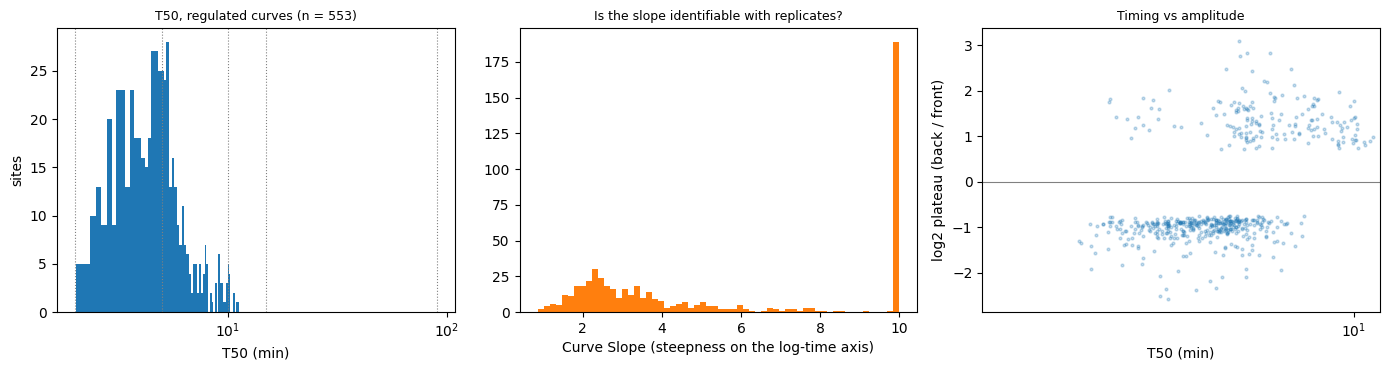

       t50_min  Curve Slope  log2_plateau  Curve RMSE
count  553.000      553.000       553.000     553.000
mean     4.916        5.571        -0.308       0.176
std      1.805        3.455         1.179       0.226
min      2.026        0.857        -2.586       0.032
25%      3.636        2.455        -1.053       0.066
50%      4.714        3.935        -0.892       0.087
75%      5.591       10.000         0.977       0.183
max     11.185       10.000         3.086       2.145


In [32]:
if curves is not None:
    _ok = curves["t50_min"].notna()
    if "Curve Regulation" in curves.columns:
        _ok &= curves["Curve Regulation"].isin(["up", "down",])

    fig, axes = plt.subplots(1, 3, figsize = (14, 3.8),)

    axes[0].hist(curves.loc[_ok, "t50_min"].clip(0, times.max(),),
                 bins  = 60,
                 color = "tab:blue",)
    for _t in times[times > 0]:
        axes[0].axvline(_t, color = "grey", ls = ":", lw = 0.8,)
    axes[0].set_xscale("symlog",)
    axes[0].set_xlabel("T50 (min)")
    axes[0].set_ylabel("sites")
    axes[0].set_title(f"T50, regulated curves (n = {int(_ok.sum())})", fontsize = 9,)

    axes[1].hist(curves.loc[_ok, "Curve Slope"], bins = 60, color = "tab:orange",)
    axes[1].set_xlabel("Curve Slope (steepness on the log-time axis)")
    axes[1].set_title("Is the slope identifiable with replicates?", fontsize = 9,)

    axes[2].scatter(curves.loc[_ok, "t50_min"],
                    curves.loc[_ok, "log2_plateau"],
                    s     = 4,
                    alpha = 0.25,)
    axes[2].axhline(0, color = "grey", lw = 0.8,)
    axes[2].set_xscale("symlog",)
    axes[2].set_xlabel("T50 (min)")
    axes[2].set_ylabel("log2 plateau (back / front)")
    axes[2].set_title("Timing vs amplitude", fontsize = 9,)

    fig.tight_layout()
    plt.show()

    print(curves.loc[_ok, ["t50_min", "Curve Slope", "log2_plateau", "Curve RMSE",]]
          .describe().round(3,).to_string())

## Cross-check against the anchored fits

The two implementations differ in model (anchored 3-parameter vs 4-parameter with `front`
fixed), in the data they see (6-point mean vs 24 replicate points), in the space they fit
(log2 FC vs ratio) and in normalisation (none vs median-centred). Agreement on T50 would be a
genuine mutual validation; disagreement localises which of those four differences matters.

Read the **rank correlation**, not the scatter about the diagonal: `clustering_method_decision.md`
already established that per-site T50 has an SE of ~2.5 min against a biological IQR of ~3.1 min,
so T50 is a set-level statistic. What has to survive is the *ordering* of sites.

### 📖 Explainer — how to read the cross-check

The two implementations differ in **four** ways at once, so this comparison confirms or localises,
it does not isolate:

| | `Sigmoid_fitting.ipynb` | this notebook |
|---|---|---|
| model | anchored 3-parameter, steepness fixed at 10 | 4-parameter with `front` fixed, slope estimated |
| data | 6-point mean profile, SEM-weighted | 24 individual replicate points |
| space | log2 fold change | ratio to control |
| normalisation | none | median-centred |

**Read the rank correlation (Spearman), not the scatter about the diagonal.** Spearman correlates
the *orderings* rather than the values (`Sigmoid_fitting.ipynb` Explainer 4). This is not a
convenience: `clustering_method_decision.md` established that per-site T50 has a standard error of
about 2.5 min against a biological spread (IQR) of about 3.1 min. Individual T50 values are
therefore not separable from one another — T50 is a **set-level** statistic, good for "these
substrates respond before those" and not for "site X responds at 7.3 min". What has to survive
between implementations is the ordering.

How to read the outcomes:

- **High rank correlation, small median offset** → the T50 ordering is a property of the data. Both
  methods can be used, and the choice between them can be made on the slope question instead.
- **High rank correlation, systematic offset** → the methods agree on timing but disagree on level.
  The prime suspect is normalisation, since only this notebook median-centres.
- **Low rank correlation** → the difference matters and must be tracked down before either T50 set
  is used. Start by splitting the comparison by `shape_class` and by whether the site is censored at
  the 2 min bound, where ranks are noise in both methods anyway.

Only sites that both methods fitted successfully enter the comparison (`fit_ok` on one side, a
non-missing `t50_min` on the other), so the `n` printed is itself informative: a large drop means the
two disagree about which sites are fittable, which is a finding in its own right.


Sites fitted by both methods: 1319
Spearman rho, T50      : -0.003
Spearman rho, plateau  : 0.962
Median T50 difference  : +1.66 min  (CurveCurator - anchored)


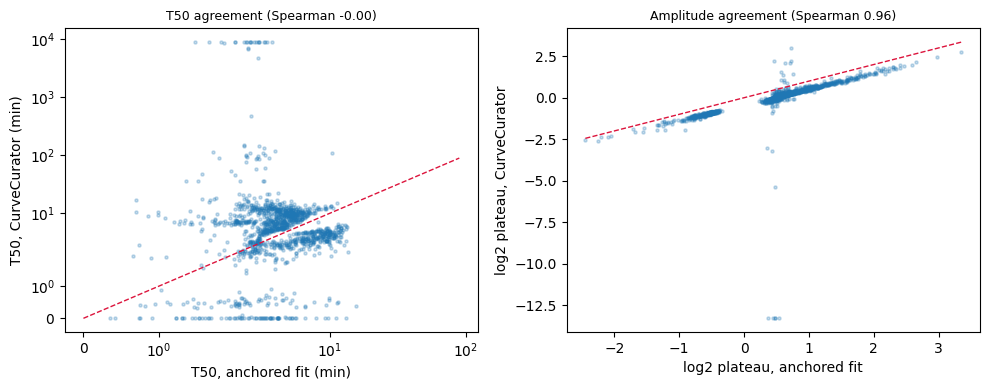

In [33]:
if curves is not None and os.path.exists(ANCHORED_FITS,):
    anchored = pd.read_csv(ANCHORED_FITS, sep = "\t", low_memory = False,)
    anchored = anchored.loc[anchored["fit_ok"] == True,
                            ["site", "t_half_min", "plateau", "shape_class",]]

    both = curves.merge(anchored,
                        on       = "site",
                        how      = "inner",
                        suffixes = ("_cc", "_anchored",),)
    both = both[both["t50_min"].notna() & both["t_half_min"].notna()]
    print(f"Sites fitted by both methods: {len(both)}")

    if len(both) > 2:
        _rho = both[["t50_min", "t_half_min",]].corr(method = "spearman",).iloc[0, 1]
        _r   = both[["log2_plateau", "plateau",]].corr(method = "spearman",).iloc[0, 1]
        _med = (both["t50_min"] - both["t_half_min"]).median()
        print(f"Spearman rho, T50      : {_rho:.3f}")
        print(f"Spearman rho, plateau  : {_r:.3f}")
        print(f"Median T50 difference  : {_med:+.2f} min  (CurveCurator - anchored)")

        fig, axes = plt.subplots(1, 2, figsize = (10, 4),)
        axes[0].scatter(both["t_half_min"], both["t50_min"], s = 5, alpha = 0.25,)
        axes[0].plot([0, times.max()], [0, times.max()], color = "crimson", ls = "--", lw = 1,)
        axes[0].set_xscale("symlog",); axes[0].set_yscale("symlog",)
        axes[0].set_xlabel("T50, anchored fit (min)")
        axes[0].set_ylabel("T50, CurveCurator (min)")
        axes[0].set_title(f"T50 agreement (Spearman {_rho:.2f})", fontsize = 9,)

        axes[1].scatter(both["plateau"], both["log2_plateau"], s = 5, alpha = 0.25,)
        _lim = [both["plateau"].min(), both["plateau"].max()]
        axes[1].plot(_lim, _lim, color = "crimson", ls = "--", lw = 1,)
        axes[1].set_xlabel("log2 plateau, anchored fit")
        axes[1].set_ylabel("log2 plateau, CurveCurator")
        axes[1].set_title(f"Amplitude agreement (Spearman {_r:.2f})", fontsize = 9,)
        fig.tight_layout()
        plt.show()
else:
    print("Need both a curves file and ANCHORED_FITS for the comparison.")

## Example curves

Drawn with `logistic_response`, which reimplements `curve_curator.models.LogisticModel.core`, so
the curve shown is the fitted model and not an approximation of it.

The observed points come from CurveCurator's **`Ratio N`** columns via
`curvecurator_observed_matrix`. That detail matters: the curves file carries `Raw N`,
`Normalized N` and `Ratio N`, the fit is against `Ratio`, and `Ratio` is derived from the
*normalised* values. Re-deriving ratios from `Raw` — the obvious thing to do — disagrees with
what was fitted by up to **4.3** on this run, because `normalization = true`, and would draw
points that do not sit on their own curve.

### 📖 Explainer — why the points come from `Ratio N`, not from `Raw N`

A plotting detail with a real trap in it.

CurveCurator's output carries the observed values at three stages: `Raw N` (as supplied),
`Normalized N` (after median centring, since `normalization = true`) and `Ratio N` (normalised value
÷ mean of the control channels). **The fit is against `Ratio`.**

So the points plotted next to a fitted curve must be the `Ratio` columns. Re-deriving ratios from
`Raw` — the obvious thing to do, since `Raw` is the data you handed over — disagrees with what was
actually fitted by up to **4.3** on this run, because normalisation sits between the two. The plot
would show points scattered away from their own curve and invite a hunt for a bug in the fitting.
`curvecurator_observed_matrix(..., prefer="Ratio")` exists to prevent that.

`logistic_response` reimplements `curve_curator.models.LogisticModel.core` exactly, so the drawn
curve is the fitted model rather than a smooth approximation of it. The six panels show the fits
with the smallest `Curve RMSE` — a smoke test that curve and points agree at all, before any
interpretation.


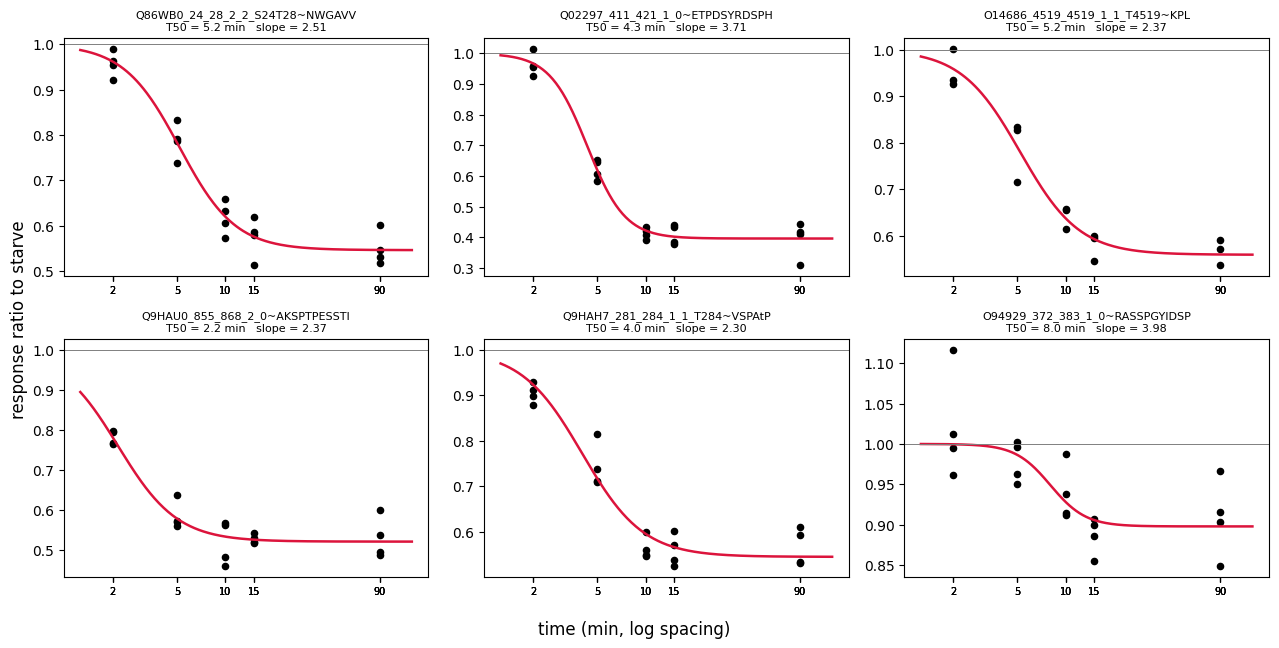

In [34]:
# The best-determined fits in the run, as a smoke test that curve and points agree.
_ok    = curves["t50_min"].notna() & np.isfinite(curves["t50_min"],)
_show  = curves.loc[_ok].nsmallest(6, "Curve RMSE",).index

_obs, _is_ctrl = curvecurator_observed_matrix(curves,
                                              design,
                                              prefer = "Ratio",)
_minutes = design["minutes"].to_numpy(dtype = float,)
_treated = _minutes > 0
_x       = np.log10(_minutes[_treated] * float(DOSE_SCALE,),)
_grid    = np.linspace(_x.min() - 0.2, _x.max() + 0.2, 300,)

fig, axes = plt.subplots(2, 3, figsize = (13, 6.5),)
for _pos, _ax in zip(_show, axes.ravel(),):
    _row = curves.loc[_pos]
    _ax.plot(_grid,
             logistic_response(_grid,
                               _row["pEC50"],
                               _row["Curve Slope"],
                               _row["Curve Front"],
                               _row["Curve Back"],),
             color = "crimson",
             lw    = 1.8,)
    _ax.scatter(_x, _obs[curves.index.get_loc(_pos,)][_treated], s = 20, color = "black",)
    _ax.axhline(1.0, color = "grey", lw = 0.7,)
    _ax.set_xticks(_x,)
    _ax.set_xticklabels([f"{t:g}" for t in _minutes[_treated]], fontsize = 7,)
    _ax.set_title(f"{str(_row['site'])[:30]}\nT50 = {_row['t50_min']:.1f} min   "
                  f"slope = {_row['Curve Slope']:.2f}",
                  fontsize = 8,)
fig.supxlabel("time (min, log spacing)")
fig.supylabel("response ratio to starve")
fig.tight_layout()
plt.show()

## All fitted sigmoids for one protein

The same per-protein view as `Sigmoid_fitting.ipynb`, on CurveCurator's output:
`plot_protein_curvecurator_fits` draws one panel per phosphosite of a protein with the curve
fitted to it, plus an overlay putting all of that protein's curves on one axes so their T50s can
be compared directly.

Three differences from the anchored-fit version, all forced by the tool:

- **The y axis is a ratio to starve, not a log2 fold change**, so the reference line is at 1.
- **Every replicate is drawn**, not a mean with error bars — CurveCurator fitted the 24
  individual replicate ratios, so the scatter around the curve *is* the residual it minimised.
- **`show_control` decides whether the starve points are shown.** CurveCurator parks the zero
  dose three decades below the first timepoint, so with `show_control=True` about 60% of the
  panel is empty axis. That emptiness is real and worth seeing once — it is the gap 19% of the
  fitted T50s fall into — but `show_control=False` rescales to the sampled window and is the
  setting to use for reading the responses.

Sites CurveCurator did not classify as regulated are drawn dashed and orange with the reason in
the title, rather than hidden.

### 📖 Explainer — reading the per-protein panels

Same idea as in `Sigmoid_fitting.ipynb`: one panel per phosphosite of a protein, plus an overlay
putting all of that protein's curves on one axes so their T50s can be read against each other.
Multiple sites on one protein with clearly different T50s is a substantive result — it means the
protein is not regulated as a unit.

Three differences from the anchored-fit version, all forced by the tool:

- **The y axis is a ratio to starve, not a log2 fold change**, so the "no change" reference line is
  at **1**, not 0. A ratio of 2 = a log2 FC of 1.
- **Every replicate is drawn**, not a mean with error bars — CurveCurator fitted the 24 individual
  ratios, so the visible scatter around the curve *is* the residual it minimised. It looks noisier
  than the other notebook's plots while being the same data.
- **`show_control` decides whether the starve points appear.** CurveCurator has no way to place a
  zero dose on a log axis, so it parks it three decades below the first timepoint. With
  `show_control=True` roughly 60% of the panel is empty axis. That emptiness is honest and worth
  seeing once — it is the unsampled gap that ~19% of the fitted T50s fall into — but
  `show_control=False` rescales to the sampled window and is the setting for day-to-day reading.

Sites CurveCurator did not classify as regulated are drawn dashed and orange with the reason in the
title rather than hidden, for the same reason the other notebook draws its unfitted sites: a protein
must never look like it has three sites when it has thirty, and *which* of its sites could not be
described is part of the result.


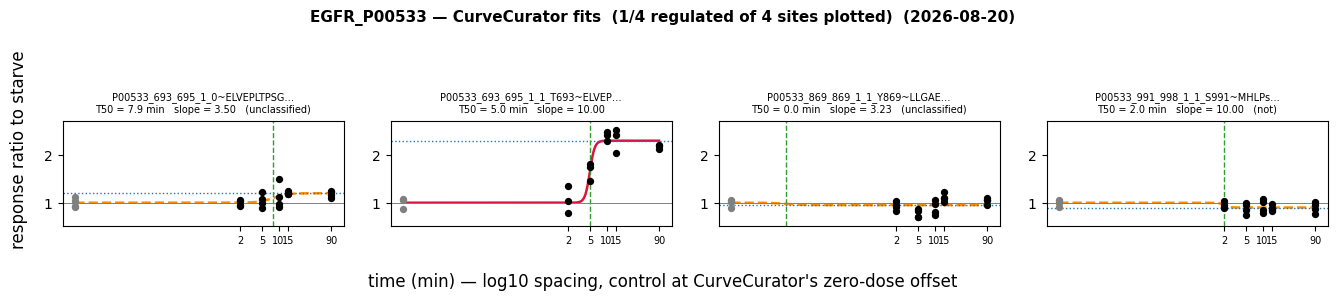

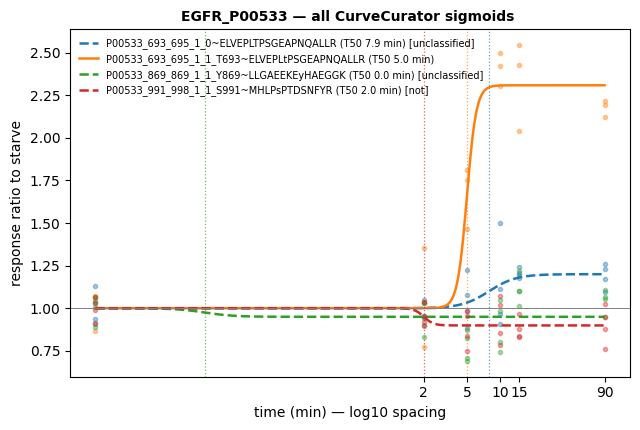

In [35]:
# One protein, faithful to the fit: the starve points sit where CurveCurator put them.
PROTEIN = "EGFR"          # accepts a protein_name or a protein_Id (UniProt accession)

if curves is not None:
    egfr_figs = plot_protein_curvecurator_fits(curves,
                                               design,
                                               PROTEIN,
                                               dose_scale   = float(DOSE_SCALE,),
                                               show_control = True,)
    plt.show()

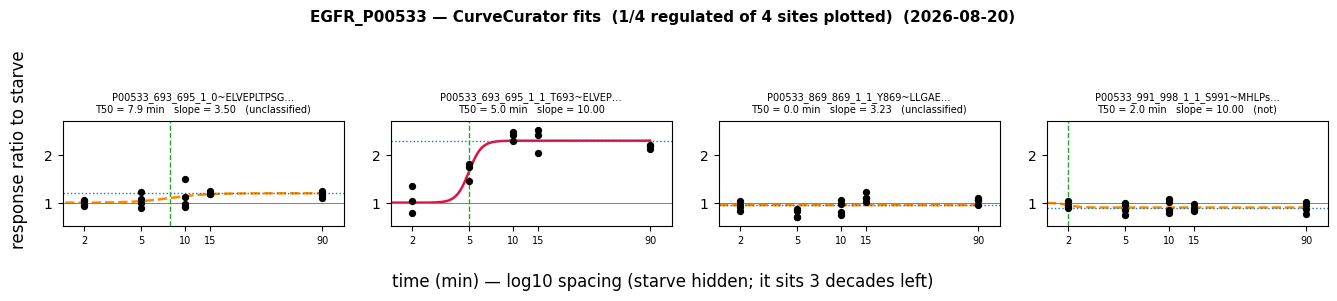

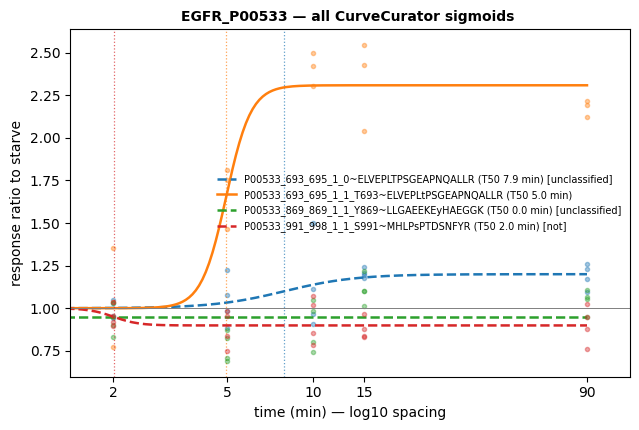

In [36]:
# The same protein without the zero-dose offset — readable, and what to use day to day.
if curves is not None:
    egfr_zoom = plot_protein_curvecurator_fits(curves,
                                               design,
                                               PROTEIN,
                                               dose_scale   = float(DOSE_SCALE,),
                                               show_control = False,)
    plt.show()


Proteins with at least one fitted site: ['BRAF']


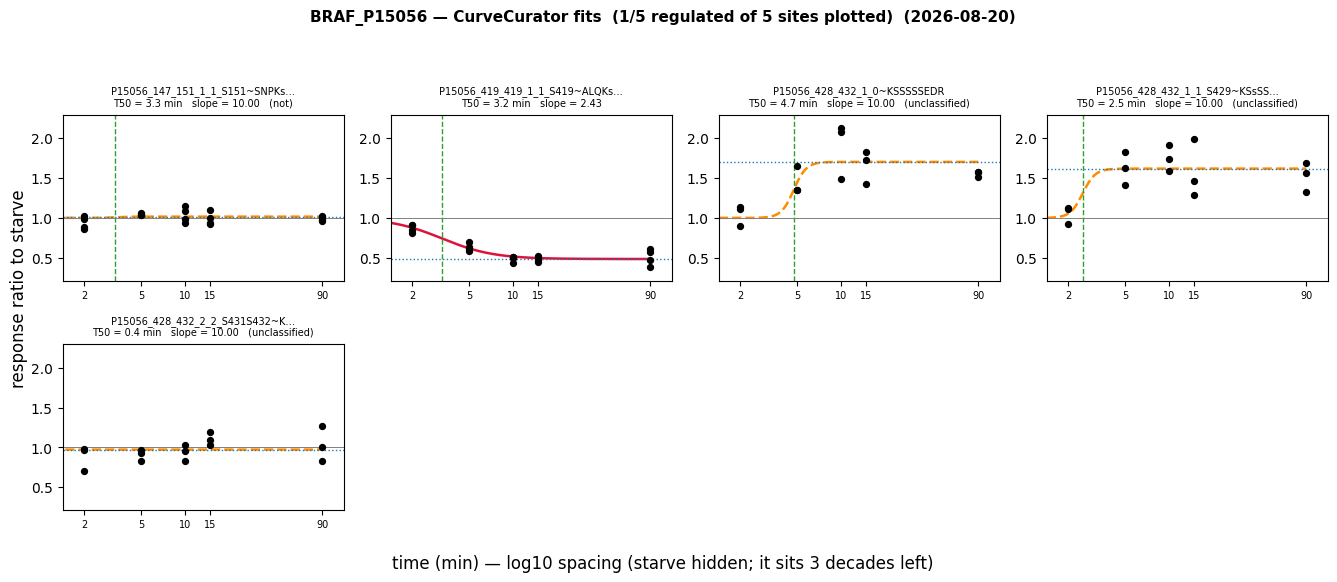

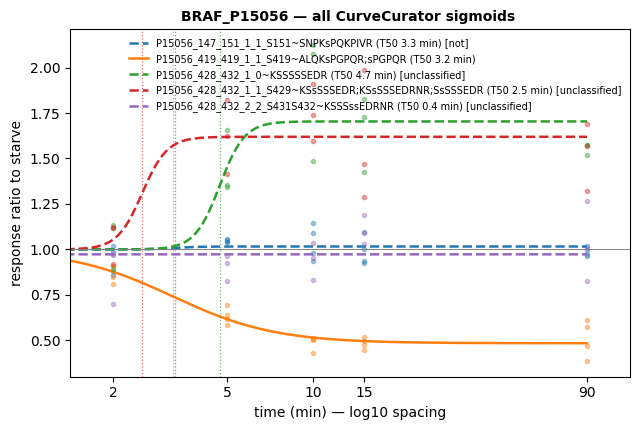

In [40]:
# A list of proteins. Heavily phosphorylated ones (SRRM2 has 91 fitted sites here) are capped
# by max_sites, which keeps the regulated ones first.
#
#   only_regulated      = True   -> only curves CurveCurator called up/down
#   include_unregulated = False  -> drop the unclassified ones but keep 'not'
PATHWAY_PROTEINS = ["BRAF"]
# ["EGFR", "SOS1", "GAB1", "BRAF", "RAF1", "MAP2K1", "MAPK1", "MAPK3",
#                     "SHC1", "GRB2", "SHOC2", "RPS6KA1", "RPS6KA3",]

if curves is not None:
    if SAVE_FIGURES:
        os.makedirs(f"{RUN_DIR}/figures", exist_ok = True,)

    protein_figs = plot_protein_curvecurator_fits(curves,
                                                  design,
                                                  PATHWAY_PROTEINS,
                                                  dose_scale   = float(DOSE_SCALE,),
                                                  show_control = False,
                                                  saving_path  = f"{RUN_DIR}/figures" if SAVE_FIGURES else "",
                                                  saving_info  = RUN_NAME,
                                                  save_pdf     = SAVE_FIGURES,
                                                  plot_close   = SAVE_FIGURES,)
    print(f"\nProteins with at least one fitted site: {sorted(protein_figs)}")

In [38]:
# The numbers behind the panels, best-determined first.
if curves is not None:
    _cols = [c for c in ["site", "shape_class", "t50_min", "Curve Slope", "log2_plateau",
                         "Curve RMSE", "Curve Regulation", "Curve q_Value",]
             if c in curves.columns]
    _tbl = curves.loc[curves["protein_name"] == PROTEIN, _cols]
    print(_tbl.sort_values("Curve RMSE",).round(3,).to_string(index = False,))

                                       site shape_class  t50_min  Curve Slope  log2_plateau  Curve RMSE Curve Regulation  Curve q_Value
      P00533_991_998_1_1_S991~MHLPsPTDSNFYR   sustained    2.011       10.000        -0.154       0.087              not          0.396
     P00533_693_695_1_0~ELVEPLTPSGEAPNQALLR   sustained    7.920        3.497         0.263       0.121              NaN          0.104
    P00533_869_869_1_1_Y869~LLGAEEKEyHAEGGK   monotonic    0.020        3.231        -0.075       0.140              NaN          0.863
P00533_693_695_1_1_T693~ELVEPLtPSGEAPNQALLR   sustained    4.963       10.000         1.207       0.175               up          0.002


## Save

One row per fitted site, with CurveCurator's own statistics kept under their original names so
they stay traceable to the tool's documentation, plus the time-domain translation.

In [39]:
# if curves is not None and SAVE_TABLE:
#     _path = f"{RUN_DIR}/{RUN_NAME}_curves_annotated.tsv"
#     curves.to_csv(_path, sep = "\t", index = False,)
#     print(f"Saved: {_path}")
# elif curves is None:
#     print("Nothing to save — CurveCurator has not been run.")
# else:
#     print("SAVE_TABLE is False — nothing written.")

## Where this goes next

- **Decide between the two implementations on the slope.** If `Curve Slope` is well determined
  here, the 24-point fit has solved the identifiability problem `Sigmoid_fitting.ipynb` had to
  work around with `DEFAULT_FIXED_K = 10`, and CurveCurator becomes the primary route. If it is
  not, the limitation is the 5-point time grid and no fitter will fix it — which is the same
  conclusion `council_note_3_temporal_curve_modelling.md` reached for the impulse model.
- **Run once with `GATE_SHAPES = False`.** The interesting question is not whether CurveCurator
  fits transient sites (it will), but whether its F-test and target-decoy FDR *reject* them.
  If they do, the shape gate is redundant and the statistics can carry the load; if they do not,
  every published CurveCurator time-series result needs a shape gate in front of it.
- **The other conditions.** Rerun with `CONDITION = "_INS_"` and `"_EGFnINS_"` and compare
  `(t50_min, log2_plateau)` per site: a T50 shift with unchanged amplitude is *timing* crosstalk,
  an amplitude shift with unchanged T50 is *gain* crosstalk.
- **Normalisation.** This notebook lets CurveCurator median-centre the intensities while the
  project pipeline does not normalise at all. That makes the two T50 sets not strictly
  comparable, and it is the most likely explanation for any systematic offset in the comparison
  above. The real fix is upstream, in `src/transformations.py`.
- **The dashboard.** CurveCurator writes an interactive Bokeh page to `dashboard.html` in the run
  directory. It is the fastest way to inspect individual fits and their replicate scatter.